# LC6 — Power system data sources and acquisition (self-paced, ~45 min)

Real analysis starts with real data. This notebook takes you from "where does power system data live?" to a cached, provenance-stamped fetch from the ENTSO-E Transparency Platform — the pattern your Lab 5 pipeline builds on. Material from this notebook appears in **Quiz 2**.

**How to use this notebook:** run the cells top to bottom, one at a time. Every code cell has a short note above it saying what the cell is for and what you should see when it runs — if what you see differs, stop there and ask your pod before moving on. Grey text after an output says how to read it.

**You need:** your ENTSO-E API token (requested during course setup). No token yet? Every cell still runs — the fetch falls back to a bundled sample so you can complete the notebook offline, but do the real fetch before Lab 5.

## 1. Where the data lives — a five-minute tour

- **[ENTSO-E Transparency Platform](https://transparency.entsoe.eu)** — the European hub: load, generation per type, day-ahead prices, cross-border flows. Web GUI for browsing, REST API for programs. This is today's workhorse.
- **TSO data pools** — [Svenska kraftnät (Mimer)](https://mimer.svk.se), [Fingrid open data](https://data.fingrid.fi), Statnett. Often richer than ENTSO-E for their own area.
- **[Open Infrastructure Map](https://openinframap.org)** — the grid itself, from OpenStreetMap data.
- **System state files** — the CGMES snapshots you meet in Lecturecise 8: not measurements over time but the *network* at an instant.

Three questions to ask of any source, always: who publishes it, what exactly does a value mean (metered? forecast? aggregated how?), and what are you allowed to do with it.

### 1.1 Setup: install and locate

`%pip install ...` runs pip inside the notebook's own Python, so the packages land where the notebook can import them; `--quiet` hides the download log. **What you see:** one line, "Note: you may need to restart the kernel…", or nothing at all — both fine. If you opened this notebook from the course venv built from `requirements.txt`, everything is already there and nothing is installed.

In [1]:
# Install exactly what this notebook uses (transitive deps come along).
%pip install entsoe-py pandas pyarrow matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


The guard: `assert <condition>, <message>` stops the notebook right here with the message if the condition is false — the same `assert` as in your tests. **What you see:** no output at all. That is the good outcome; every `../data/...` path below relies on it.

In [2]:
from pathlib import Path
# Guard: this notebook expects to run from the notebooks/ folder of a clone of
# the course repository — the datasets live one level up in ../data/.
# Failing here, early and clearly, beats a confusing FileNotFoundError later.
assert Path("../data").exists(), (
    "Course data folder not found. Clone KTH-EG2140/course-material and open "
    "this notebook from its notebooks/ folder.")

## 2. Your token

The API wants a token with every request. Never hardcode it in a notebook you will commit — read it from a file or an environment variable (this is the pattern for every secret, all course long):

Two things in this cell. `Path("entsoe_token.txt")` is a file *next to this notebook* (the path is relative to the folder the notebook runs in); `.read_text().strip()` reads it and drops the newline. The long line is Python's one-line conditional — *this value if the file exists, otherwise that one* — the form you met in Lab 3; here it falls back to the environment variable, and to `None` if that is unset too. **What you see:** `token found`, or `no token — the notebook will use the offline fallback`. Both let you continue.

In [3]:
import os
from pathlib import Path

# Option A: a file next to this notebook (add it to .gitignore!)
# Option B: an environment variable ENTSOE_TOKEN
token_file = Path("entsoe_token.txt")
TOKEN = token_file.read_text().strip() if token_file.exists() else os.environ.get("ENTSOE_TOKEN")
print("token found" if TOKEN else "no token — the notebook will use the offline fallback")

no token — the notebook will use the offline fallback


## 3. Fetch with a cache

Two rules of API citizenship: **never fetch the same thing twice** (a cache), and **record where every dataset came from** (provenance). Both in one small function:

In the lecture the same fetch was one raw REST call: `documentType=A65` (actual total load) against a zone's **EIC code** — the example queried SE4 by its code `10Y1001A1001A47J`. The `entsoe-py` client below wraps exactly that request: when you write `"SE_3"`, the library looks up the zone's EIC code (`10Y1001A1001A46L`) and fills in the document type for you. Same API, same parameters — the library just does the bookkeeping.


### 3.1 The function

Read `cached_load` top to bottom before running it — this is the shape Lab 5 asks you to build into the toolbox as `fetch_load`. Constructs you meet here for the first time:

- `f"load_{zone}_{start}_{end}"` builds the cache **key** from the three arguments, so the same question always maps to the same file name.
- `CACHE / f"{key}.parquet"` joins folder and file name with `/`, as `loader.py` does for `DATA_DIR`; `pq.exists()` asks whether that file is already there — the cache hit.
- The `import` inside the function runs only when the function reaches it, so a laptop that only ever hits the cache never needs the `entsoe` library to work.
- `client.query_load(...)` answers with a table of one column per source resolution; `s.iloc[:, 0]` takes *all rows, first column* (position-based indexing, `[rows, columns]`).
- `.resample("1h").mean()` regroups the readings into one-hour bins and averages each — some zones report every 15 minutes. LC7 treats resampling properly; here it is just "make it hourly".
- A Series has no `to_parquet`, so `.to_frame()` turns it into a one-column table first. `json.dumps(..., indent=2)` writes the sidecar as readable text; `datetime.now(timezone.utc).isoformat()` stamps the fetch time in UTC.

**What you see:** nothing — the cell only *defines* the function. The next cell calls it.

In [4]:
import json
from datetime import datetime, timezone

import pandas as pd

CACHE = Path("data_cache"); CACHE.mkdir(exist_ok=True)

def cached_load(zone: str, start: str, end: str) -> pd.Series:
    """Hourly actual load for an ENTSO-E zone, cached in Parquet with a provenance sidecar."""
    key = f"load_{zone}_{start}_{end}"
    pq, meta = CACHE / f"{key}.parquet", CACHE / f"{key}.json"
    if pq.exists():
        print(f"cache hit: {pq.name}")
        return pd.read_parquet(pq)["load_mw"]
    from entsoe import EntsoePandasClient          # imported here: offline users never need it
    client = EntsoePandasClient(api_key=TOKEN)
    s = client.query_load(zone, start=pd.Timestamp(start, tz="Europe/Stockholm"),
                          end=pd.Timestamp(end, tz="Europe/Stockholm"))
    s = s.iloc[:, 0].resample("1h").mean().rename("load_mw")   # 15-min zones -> hourly
    s.to_frame().to_parquet(pq)
    meta.write_text(json.dumps({
        "source": "ENTSO-E Transparency, query_load", "zone": zone,
        "period": [start, end], "retrieved_utc": datetime.now(timezone.utc).isoformat(),
        "unit": "MW, hourly mean of source resolution"}, indent=2))
    print(f"fetched and cached: {pq.name}")
    return s

### 3.2 The call — online or offline, honestly labelled

The `try` block runs the real fetch. Without a token it *raises on purpose* (`raise RuntimeError("no token")`), which jumps straight into the `except` block — a deliberate use of the mechanism from LC3, so the notebook takes the offline road instead of crashing. The fallback slices June out of the course sample: `.loc["2025-06-01":"2025-06-30"]` is date-string slicing on a time index, and unlike list slicing it includes **both** ends — 30 days × 24 hours = 720 rows.

**What you see, without a token:**

```
[offline fallback: RuntimeError: no token]
COURSE SAMPLE (offline fallback) — not ENTSO-E | 720 hours | mean 2538 MW
```

**With a token:** `fetched and cached: load_SE_3_2025-06-01_2025-07-01.parquet` the first time, `cache hit: ...` the second, then `ENTSO-E (live or cache) | 720 hours | mean <a few thousand> MW` — SE3 is the Stockholm bidding zone, so a June mean of a few thousand MW is right. A `429` error means the API is rate-limiting you: wait a minute and rerun (section 4).

In [5]:
# The real thing (needs the token) — with an honest offline fallback.
try:
    if not TOKEN:
        raise RuntimeError("no token")
    load = cached_load("SE_3", "2025-06-01", "2025-07-01")
    SOURCE = "ENTSO-E (live or cache)"
except Exception as e:
    print(f"[offline fallback: {type(e).__name__}: {e}]")
    # course sample — SAME SHAPE as the real answer, clearly labelled, so the
    # rest of the notebook works on the train. Do the real fetch before Lab 5.
    df = pd.read_parquet("../data/svedala-year/svedala_hourly.parquet")
    load = df["ZON_MITT"].loc["2025-06-01":"2025-06-30"].rename("load_mw")
    SOURCE = "COURSE SAMPLE (offline fallback) — not ENTSO-E"
print(SOURCE, "|", len(load), "hours |", f"mean {load.mean():.0f} MW")

[offline fallback: RuntimeError: no token]


COURSE SAMPLE (offline fallback) — not ENTSO-E | 720 hours | mean 2538 MW


Run the fetch cell **twice** and watch the second run hit the cache — that is the whole point. Then look inside `data_cache/`: the `.json` sidecar is the dataset's birth certificate. (Offline, the folder exists but stays empty: the fallback reads the sample straight from `../data/` and never writes a cache — the cache-hit line and the sidecar appear only once you fetch with a token.) When someone asks "where is this number from?" in your project, that file is the answer.

### 3.3 Look at it

`load.plot(...)` draws the Series and hands back the *axes* object, which is why the next line can set the y-label on it; the trailing `;` after the last statement stops Jupyter from also printing the object's text form. **What you see:** thirty days of hourly load with a clear daily rhythm — evenings high, nights low — and lower weekends. The title tells you which source you are looking at.

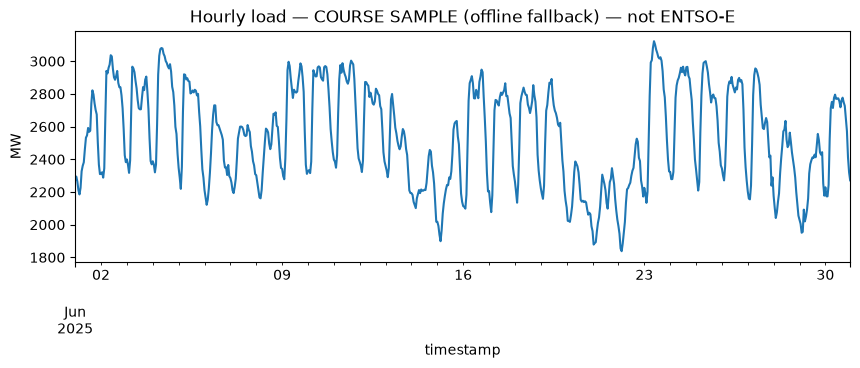

In [6]:
ax = load.plot(figsize=(10, 3), title=f"Hourly load — {SOURCE}")
ax.set_ylabel("MW");

## 4. Rate limits and manners

The Transparency API allows a limited number of requests per minute and will lock you out if you hammer it (HTTP 429). Consequences for how you write code: fetch **big chunks rarely** (a month, not 720 single hours), cache everything, and put a `time.sleep(1)` between calls in any loop. Your Lab 5 pipeline is expected to survive a rerun without re-fetching a single byte.

## 5. Self-check

All three should pass — offline or online:

Three `assert` lines, each with its message: at least 28 days of hours; `load.notna().mean()` is the share of hours that have a value (True/False averaged, the Lab 2 idiom) and must be above 95 %; and `500 < load.mean() < 50000` is a chained comparison — the mean must sit between two bounds that any real zone satisfies. **What you see:** `ALL OK — <your source>`, plus a reminder line if you are on the fallback.

In [7]:
assert len(load) >= 24 * 28, "expected at least a month of hourly data"
assert load.notna().mean() > 0.95, "too many gaps"
assert 500 < load.mean() < 50000, "mean load outside any plausible zone range"
print("ALL OK —", SOURCE)
if "fallback" in SOURCE:
    print("…but do the real ENTSO-E fetch before Lab 5. The quiz assumes you have.")

ALL OK — COURSE SAMPLE (offline fallback) — not ENTSO-E
…but do the real ENTSO-E fetch before Lab 5. The quiz assumes you have.


## 6. What you take to Lab 5

Three habits, now in your fingers: **cache first** (the key names the question, the file answers it, and the second run touches no network), **provenance next to the data** (the sidecar says where, when and in what unit), and **the token never in code** (a file that git ignores, or an environment variable). Lab 5 asks for exactly these three as `fetch_load` in the toolbox, with a test that passes without a token — the cache is what makes that possible.